In [6]:
from ntupelizer.aleph.tools import create_aleph as na

from typing import List, Optional

import awkward as ak
import fastjet
import numpy as np
import uproot
import vector

from ntupelizer.tools import features as f

from ntupelizer.aleph.tools import event_variable_calculations as evc
from ntupelizer.aleph.tools import jet_variable_calculations as jvc

from ntupelizer.aleph.tools.create_aleph import *

In [7]:
input_path = "/local/laurits/ALEPH/1994_old/LAST/2057/data_2057_1.root"
output_path = "test.parquet"

In [8]:
events = load_file_contents(path=input_path, tree_name="events")
combined_jet, particle_data = construct_jet_based_dataset(events)


Clustered 50940 jets with R=0.8


NameError: name 'jet_level' is not defined

In [27]:
event_dataset.fields

['jet_pt',
 'jet_eta',
 'jet_phi',
 'jet_energy',
 'jet_mass',
 'jet_sdmass',
 'jet_tau1',
 'jet_tau2',
 'jet_tau3',
 'jet_tau4',
 'jet_mass_from_p4s',
 'jet_pt_from_p4s',
 'jet_eta_from_p4s',
 'jet_phi_from_p4s',
 'jet_nparticles',
 'part_ptrel',
 'part_erel',
 'part_etarel',
 'part_phirel',
 'part_deltaR',
 'part_deta',
 'part_dphi',
 'part_px',
 'part_py',
 'part_pz',
 'part_energy',
 'part_pt',
 'part_eta',
 'part_phi',
 'part_mass',
 'part_d0val',
 'part_d0err',
 'part_dzval',
 'part_dzerr',
 'part_charge',
 'part_isChargedHadron',
 'part_isNeutralHadron',
 'part_isPhoton',
 'part_isElectron',
 'part_isMuon']

In [25]:
particle_data

<Array [[], [], [], [], ..., [...], [], [], []] type='63320 * var * {part_p...'>

In [31]:
combined_jet = ak.Array(combined_jet)

In [58]:
from ntupelizer.aleph.tools.event_variable_calculations import *

In [35]:
combined_jet[0]

<Record {jet_pt: [1.46, ...], jet_eta: ..., ...} type='{jet_pt: var * float...'>

In [41]:
{**particle_data}

TypeError: 'Array' object is not a mapping

In [49]:
particle_data.fields

['part_p4',
 'part_px',
 'part_py',
 'part_pz',
 'part_energy',
 'part_pt',
 'part_eta',
 'part_phi',
 'part_mass',
 'part_d0val',
 'part_d0err',
 'part_dzval',
 'part_dzerr',
 'part_charge',
 'part_isChargedHadron',
 'part_isNeutralHadron',
 'part_isPhoton',
 'part_isElectron',
 'part_isMuon']

In [55]:
        bad_particle = (
            (particle_data.part_pt <= 0)
            | (particle_data.part_energy >= 45.6)
            | (particle_data.part_pt == -999.9)
            | (~np.isfinite(particle_data.part_pt))
        )
        event_contains_bad_particle = ak.any(bad_particle, axis=-1)
        bad_jets = (
            (combined_jet.jet_pt < 0)
            | ~np.isfinite(combined_jet.jet_eta)
            | (combined_jet.jet_energy > 91.2)
        )
        event_contains_bad_jet = ak.any(bad_jets, axis=-1)
        event_mask_ = ak.num(combined_jet.jet_pt) > 0
        event_mask = (
            (~event_contains_bad_particle) & (~event_contains_bad_jet) & event_mask_
        )
        particle_data = particle_data[event_mask]
        combined_jet = combined_jet[event_mask]

In [ ]:
def compute_thrust(particle_data: ak.Array) -> ak.Array:
    """Event thrust T = max over n of sum_i |p_i . n| / sum_i |p_i|.

    Args:
        particle_data: [events, particles] with part_px, part_py, part_pz fields

    Returns:
        [events] thrust values (between 0.5 and 1.0)
    """
    thrust_values = []

    for event_px, event_py, event_pz in zip(
        particle_data.part_px, particle_data.part_py, particle_data.part_pz
    ):
        T, _ = thrust_3d(
            np.asarray(event_px), np.asarray(event_py), np.asarray(event_pz)
        )
        thrust_values.append(T)

    thrust_values = np.array(thrust_values)
    return thrust_values

In [59]:
        event_dataset = evc.get_event_variables(
            particle_data=particle_data, jet_data=combined_jet
        )

NameError: name 'thrust' is not defined

In [44]:
particle_data


<Array [[{part_p4: {...}, ...}, ...], ...] type='16711 * var * {part_p4: Mo...'>

In [64]:
eigenvalues = compute_eigenvalues(particle_data)

In [65]:
eigenvalues

<Array [[1.32e-05, 0.00124, 0.999], ..., [...]] type='16711 * 3 * float32'>

In [67]:
apl = compute_aplanarity(eigenvalues=eigenvalues)

In [68]:
sph = compute_sphericity(eigenvalues=eigenvalues)

(array([1.0000e+01, 5.4000e+01, 1.0900e+02, 1.7100e+02, 2.9000e+02,
        4.0200e+02, 6.2000e+02, 9.0600e+02, 1.6440e+03, 1.2505e+04]),
 array([0.65269607, 0.73742652, 0.82215691, 0.90688729, 0.99161774,
        1.07634819, 1.16107857, 1.24580908, 1.33053946, 1.41526985,
        1.50000024]),
 <BarContainer object of 10 artists>)

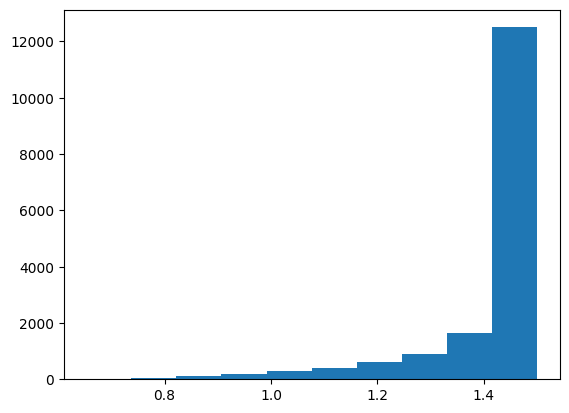

In [69]:
plt.hist(apl)

(array([1.2505e+04, 1.6440e+03, 9.0600e+02, 6.2000e+02, 4.0200e+02,
        2.9000e+02, 1.7100e+02, 1.0900e+02, 5.4000e+01, 1.0000e+01]),
 array([-5.88671298e-08,  8.47303569e-02,  1.69460773e-01,  2.54191190e-01,
         3.38921607e-01,  4.23652023e-01,  5.08382440e-01,  5.93112886e-01,
         6.77843273e-01,  7.62573659e-01,  8.47304106e-01]),
 <BarContainer object of 10 artists>)

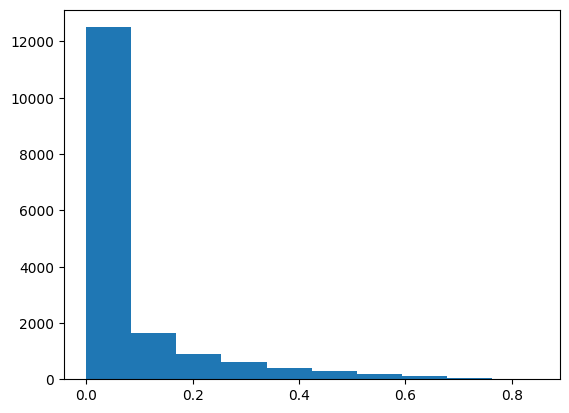

In [70]:
plt.hist(sph)

In [60]:
def compute_thrust(particle_data: ak.Array) -> ak.Array:
    """Event thrust T = max over n of sum_i |p_i . n| / sum_i |p_i|.

    Args:
        particle_data: [events, particles] with part_px, part_py, part_pz fields

    Returns:
        [events] thrust values (between 0.5 and 1.0)
    """
    thrust_values = []

    for event_px, event_py, event_pz in zip(
        particle_data.part_px, particle_data.part_py, particle_data.part_pz
    ):
        T, _ = thrust_3d(
            np.asarray(event_px), np.asarray(event_py), np.asarray(event_pz)
        )
        thrust_values.append(T)

    thrust_values = np.array(thrust_values)
    return thrust_values

In [61]:
compute_thrust(particle_data)

array([0.99604475, 0.99999994, 0.9192834 , ..., 1.        , 0.97008413,
       0.99759924], shape=(16711,), dtype=float32)

In [62]:
thr = _

(array([2.0000e+01, 6.0000e+00, 1.5000e+01, 3.3000e+01, 8.5000e+01,
        1.5200e+02, 3.0800e+02, 7.4500e+02, 1.9860e+03, 1.3361e+04]),
 array([3.90850357e-04, 1.00351788e-01, 2.00312734e-01, 3.00273687e-01,
        4.00234610e-01, 5.00195503e-01, 6.00156486e-01, 7.00117409e-01,
        8.00078332e-01, 9.00039256e-01, 1.00000024e+00]),
 <BarContainer object of 10 artists>)

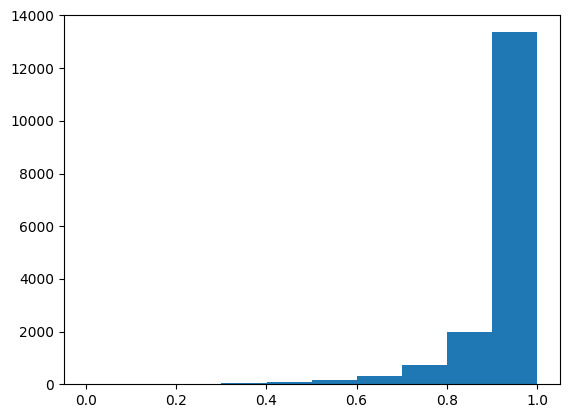

In [63]:
import matplotlib.pyplot as plt 
plt.hist(thr)

In [22]:
    px = event_dataset.part_px
    py = event_dataset.part_py
    pz = event_dataset.part_pz

    print("Sxx:", ak.type(Sxx))
    print("Sxy:", ak.type(Sxy))
    print("Sxz:", ak.type(Sxz))

    p2 = px**2 + py**2 + pz**2

    norm = ak.sum(p2, axis=-1)

    Sxx = ak.sum(px * px, axis=-1) / norm
    Syy = ak.sum(py * py, axis=-1) / norm
    Szz = ak.sum(pz * pz, axis=-1) / norm

    Sxy = ak.sum(px * py, axis=-1) / norm
    Sxz = ak.sum(px * pz, axis=-1) / norm
    Syz = ak.sum(py * pz, axis=-1) / norm

    tensor = np.stack(
        [
            np.stack([Sxx, Sxy, Sxz], axis=-1),
            np.stack([Sxy, Syy, Syz], axis=-1),
            np.stack([Sxz, Syz, Szz], axis=-1),
        ],
        axis=-2,
    )

    # eigenvalues = np.linalg.eigvalsh(tensor)

Sxx: 63320 * var * float64
Sxy: 63320 * var * float64
Sxz: 63320 * var * float64


ValueError: cannot convert to RegularArray because subarray lengths are not regular (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-48/awkward-cpp/src/cpu-kernels/awkward_ListOffsetArray_toRegularArray.cpp#L22)